In [1]:
import numpy as np
import random
import os

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


In [2]:
# =========================
# LOAD DATA + DEFINE FEATURES
# =========================

import pandas as pd

df = pd.read_excel(r"D:\Ainur Apai\IEEE Riga\app_data.xlsx")

print("Dataset shape:", df.shape)


# Radiologist (Ultrasound) Features
us_features = [
    "Appendix_on_US",
    "Appendix_Diameter",
    "Free_Fluids",
    "Appendix_Wall_Layers",
    "Target_Sign",
    "Appendicolith",
    "Perfusion",
    "Perforation",
    "Surrounding_Tissue_Reaction",
    "Appendicular_Abscess",
    "Abscess_Location",
    "Pathological_Lymph_Nodes",
    "Lymph_Nodes_Location",
    "Conglomerate_of_Bowel_Loops",
    "Ileus",
    "Coprostasis",
    "Meteorism",
    "Enteritis",
    "Gynecological_Findings"
]

# Target
target_col = "Target"

print("\nNumber of Radiologist Features:", len(us_features))

Dataset shape: (782, 58)

Number of Radiologist Features: 19


In [3]:
# =========================
# CHECK COLUMN NAMES
# =========================

print("All columns:\n")
print(df.columns.tolist())

All columns:

['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Management', 'Severity', 'Diagnosis_Presumptive', 'Diagnosis', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'US_Number', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis', 'Meteorism', 'En

In [4]:
print(df["Diagnosis"].value_counts())

Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64


In [5]:
# =========================
# TARGET CLEANING
# =========================

# Clean Diagnosis column 
df["Diagnosis"] = df["Diagnosis"].str.strip().str.lower()

# Create Target safely
df["Target"] = df["Diagnosis"].map({
    "appendicitis": 1,
    "no appendicitis": 0
})
df = df.dropna(subset=["Target"]).copy()

# Convert to int
df["Target"] = df["Target"].astype(int)

# ---- Prepare X, y again
X = df[us_features].copy()
y = df["Target"].copy()

# ---- Check
print("Target distribution:")
print(y.value_counts())

print("\nAny NaN in target?", y.isnull().sum())

Target distribution:
Target
1    463
0    317
Name: count, dtype: int64

Any NaN in target? 0


C:\Users\User\AppData\Local\Temp\ipykernel_12752\3752333645.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


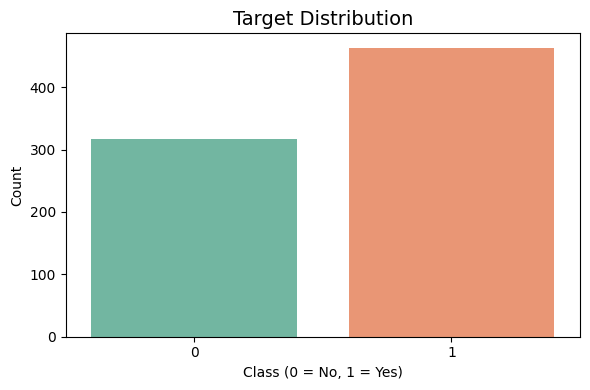

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x=y, palette="Set2")

plt.title("Target Distribution", fontsize=14)
plt.xlabel("Class (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [7]:
# =========================
# TRAIN-TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,       
    random_state=SEED
)

# ---- Checks (validation)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (624, 19)
Test shape : (156, 19)

Train target distribution:
Target
1    0.592949
0    0.407051
Name: proportion, dtype: float64

Test target distribution:
Target
1    0.596154
0    0.403846
Name: proportion, dtype: float64


In [8]:
# =========================
# PREPROCESSING PIPELINE
# =========================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ---- Identify feature types
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "bool", "category","string"]).columns.tolist()

print("Numerical features:", len(num_cols))
print("Categorical features:", len(cat_cols))


# ---- Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# ---- Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ---- Combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("\nPreprocessing pipeline ready.")

Numerical features: 1
Categorical features: 18

Preprocessing pipeline ready.


# ## Radiologist baseline model

এখানে আমরা multiple model try করছি না।  
কারণ আমাদের goal model compare করা না, বরং radiologist-level performance বুঝা।

Ultrasound features basically radiologist-এর observation represent করে।  
তাই আমরা একটা strong এবং reliable model (Random Forest) ব্যবহার করছি  
যাতে এই features থেকে decision নেওয়ার patternটা capture করা যায়।

এটা আমাদের জন্য একটা reference point হবে —  
পরে আমরা দেখবো AI model (clinical বা multimodal) এই level reach করতে পারে কিনা।

In [9]:
# =========================
#  MODEL TRAINING
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# ---- Model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1
)

# ---- Full pipeline
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", rf_model)
])

# ---- Train
pipeline.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [10]:
# =========================
# EVALUATION
# =========================

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# ---- Probabilities
probs = pipeline.predict_proba(X_test)[:, 1]

# ---- Predictions (default threshold = 0.5)
preds = pipeline.predict(X_test)

# ---- AUC
auc = roc_auc_score(y_test, probs)

print("===== Radiologist Baseline Performance =====")
print(f"AUC: {auc:.4f}")

# ---- Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

# ---- Classification Report
print("\nClassification Report:")
print(classification_report(y_test, preds))

===== Radiologist Baseline Performance =====
AUC: 0.9368

Confusion Matrix:
[[58  5]
 [12 81]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        63
           1       0.94      0.87      0.91        93

    accuracy                           0.89       156
   macro avg       0.89      0.90      0.89       156
weighted avg       0.90      0.89      0.89       156



C:\Users\User\AppData\Local\Temp\ipykernel_12752\167945605.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, y="feature", x="importance", palette="viridis")


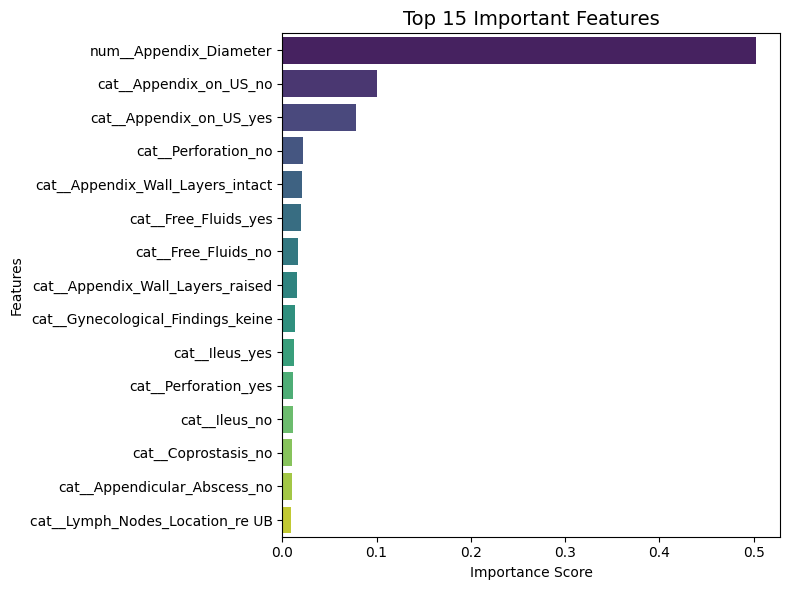

In [11]:
import pandas as pd
import numpy as np

# Extract feature importance
model = pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = pipeline.named_steps["prep"].get_feature_names_out()

importances = model.feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(15)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=feat_df, y="feature", x="importance", palette="viridis")

plt.title("Top 15 Important Features", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

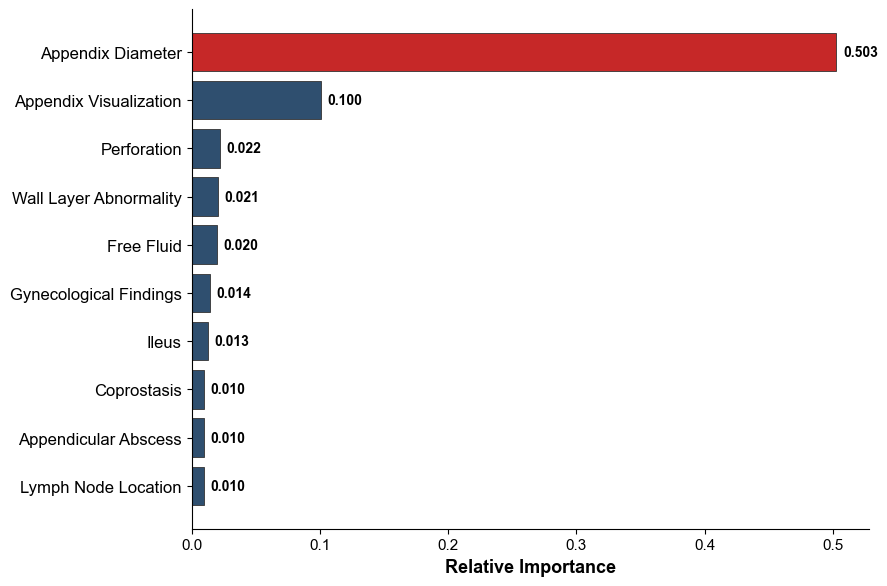

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FEATURE IMPORTANCE DATA
# ==========================================================

feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_df = (
    feat_df
    .sort_values("importance", ascending=False)
    .head(15)
    .copy()
)

# ==========================================================
# CLINICAL LABELS
# ==========================================================

rename_dict = {
    "num__Appendix_Diameter": "Appendix Diameter",

    "cat__Appendix_on_US_no": "Appendix Visualization",
    "cat__Appendix_on_US_yes": "Appendix Visualization",

    "cat__Perforation_no": "Perforation",
    "cat__Perforation_yes": "Perforation",

    "cat__Appendix_Wall_Layers_intact": "Wall Layer Abnormality",
    "cat__Appendix_Wall_Layers_raised": "Wall Layer Abnormality",

    "cat__Free_Fluids_yes": "Free Fluid",
    "cat__Free_Fluids_no": "Free Fluid",

    "cat__Gynecological_Findings_keine": "Gynecological Findings",

    "cat__Ileus_yes": "Ileus",
    "cat__Ileus_no": "Ileus",

    "cat__Coprostasis_no": "Coprostasis",
    "cat__Coprostasis_yes": "Coprostasis",

    "cat__Appendicular_Abscess_no": "Appendicular Abscess",
    "cat__Appendicular_Abscess_yes": "Appendicular Abscess",

    "cat__Lymph_Nodes_Location_re UB": "Lymph Node Location"
}

feat_df["feature"] = feat_df["feature"].replace(rename_dict)

# ==========================================================
# MERGE DUPLICATES
# ==========================================================

feat_df = (
    feat_df
    .groupby("feature", as_index=False)
    .agg({"importance": "max"})
)

feat_df = feat_df.sort_values(
    "importance",
    ascending=True
)

# ==========================================================
# COLORS
# ==========================================================
colors = []

for feature in feat_df["feature"]:
    if feature == "Appendix Diameter":
        colors.append("#C62828")  # Deep Red
    else:
        colors.append("#2F4F6F")  # Medical Blue
# ==========================================================
# FIGURE
# ==========================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11
})

fig, ax = plt.subplots(
    figsize=(9,6),
    facecolor="white"
)

bars = ax.barh(
    feat_df["feature"],
    feat_df["importance"],
    color=colors,
    edgecolor="#333333",
    linewidth=0.6
)

# ==========================================================
# IMPORTANCE VALUES
# ==========================================================

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# ==========================================================
# STYLE
# ==========================================================

ax.set_xlabel(
    "Relative Importance",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.tick_params(
    axis="y",
    labelsize=12
)

ax.tick_params(
    axis="x",
    labelsize=11
)


# ==========================================================
# SAVE
# ==========================================================

plt.tight_layout()

plt.savefig(
    "Figure5_Radiologist_FeatureImportance_Nexus.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "Figure5_Radiologist_FeatureImportance_Nexus.pdf",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

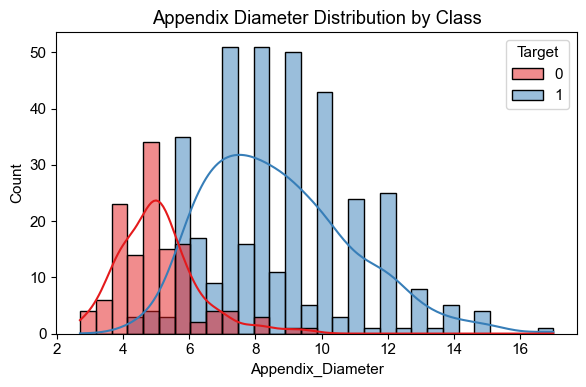

In [13]:
plt.figure(figsize=(6,4))

sns.histplot(data=df, x="Appendix_Diameter", hue="Target",
             kde=True, bins=30, palette="Set1")

plt.title("Appendix Diameter Distribution by Class")
plt.tight_layout()
plt.show()

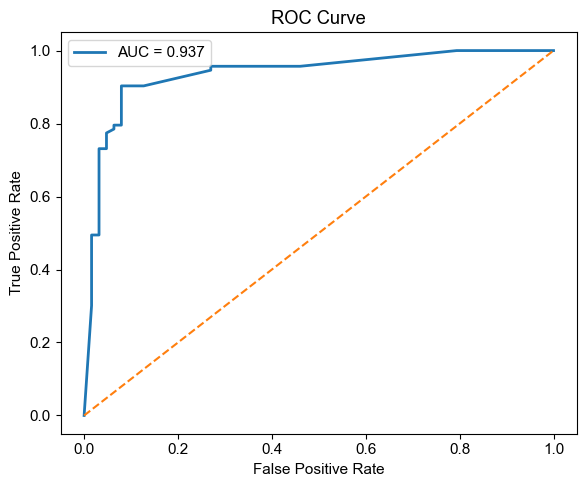

In [14]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

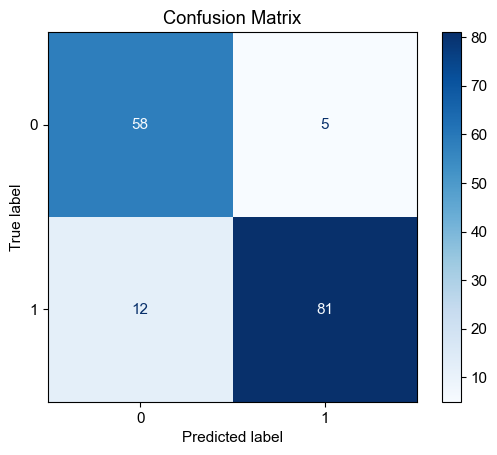

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

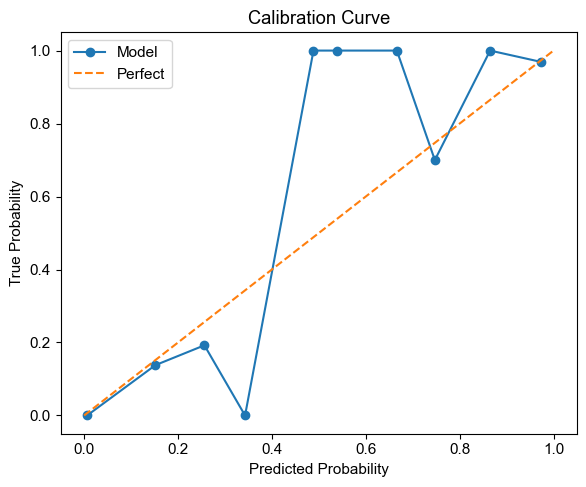

In [16]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect")

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()

plt.tight_layout()
plt.show()

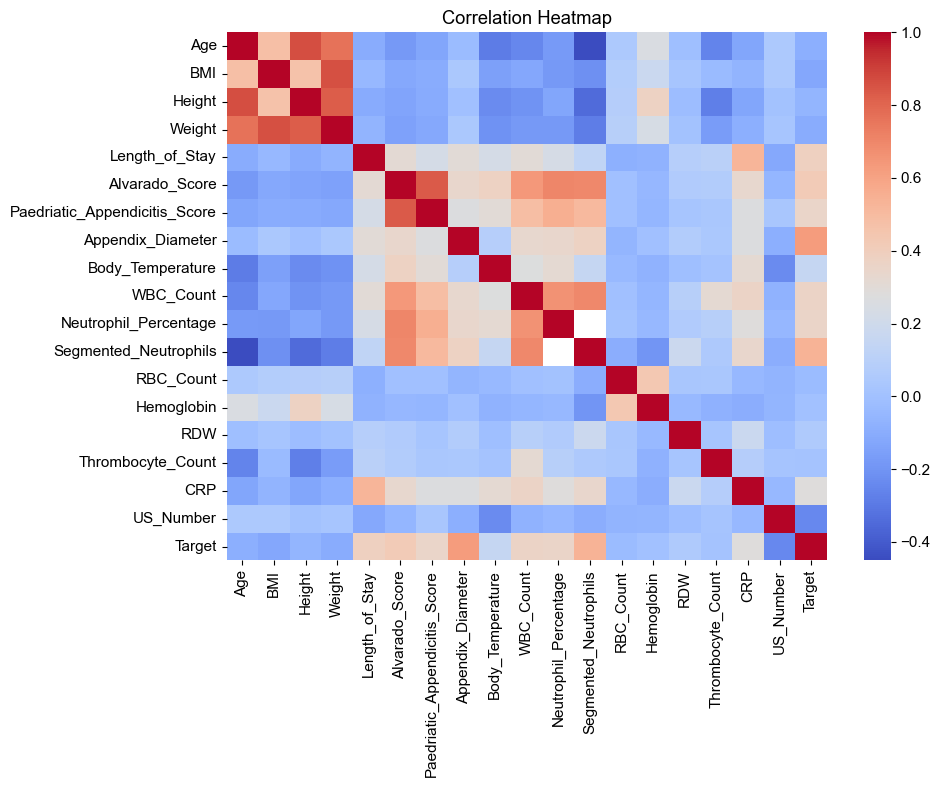

In [17]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [18]:
print(len(y_test))
print(len(probs))

156
156


In [19]:
from sklearn.metrics import roc_auc_score

print(
    roc_auc_score(
        y_test,
        probs
    )
)

0.9367639528929852


In [20]:
from sklearn.metrics import roc_auc_score
import numpy as np

def bootstrap_auc_ci(y_true, y_prob,
                     n_bootstrap=5000,
                     seed=42):

    rng = np.random.RandomState(seed)

    aucs = []

    for _ in range(n_bootstrap):

        idx = rng.choice(
            len(y_true),
            len(y_true),
            replace=True
        )

        if len(np.unique(y_true[idx])) < 2:
            continue

        aucs.append(
            roc_auc_score(
                y_true[idx],
                y_prob[idx]
            )
        )

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return (
        roc_auc_score(y_true, y_prob),
        lower,
        upper
    )

In [21]:
auc, low, high = bootstrap_auc_ci(
    np.array(y_test),
    np.array(probs)
)

print(
    f"Radiologist: "
    f"AUC={auc:.4f} "
    f"(95% CI {low:.4f}-{high:.4f})"
)

Radiologist: AUC=0.9368 (95% CI 0.8915-0.9724)
